# Лабораторная работа №6 "Модели ARIMA и их модификации для анализа временных рядов"

# Цель работы
Освоить методы моделирования временных рядов на основе ARIMA-подхода и
его расширений (SARIMA, SARIMAX), а также получить практические навыки
построения, диагностики и выбора моделей временных рядов в условиях, приближенных к задачам реального Data Science.

# Задания:
# Задание 1. Анализ и подготовка временного ряда
Студент самостоятельно выбирает набор данных, удовлетворяющий
следующим условиям:
- временной ряд должен иметь не менее 200 наблюдений;
- наличие временной метки (дата/время);
- желательно наличие сезонности или тренда;
- допускаются данные из областей:
  * финансы (курсы валют, акции);
  * продажи и спрос; (наш случай)
  * погодные данные;
  * энергетика (нагрузка, потребление);
  * веб-аналитика.

  
Требуется:
- Построить график временного ряда.
- Описать его структуру (тренд, сезонность, выбросы).
- Проверить стационарность с помощью теста Дики-Фуллера (ADF).
- Привести ряд к стационарному виду (дифференцирование (при
необходимости несколько раз), логарифмирование или Box-Cox преобразование) и
повторно проверить на стационарность.
- Обосновать выбор преобразований.

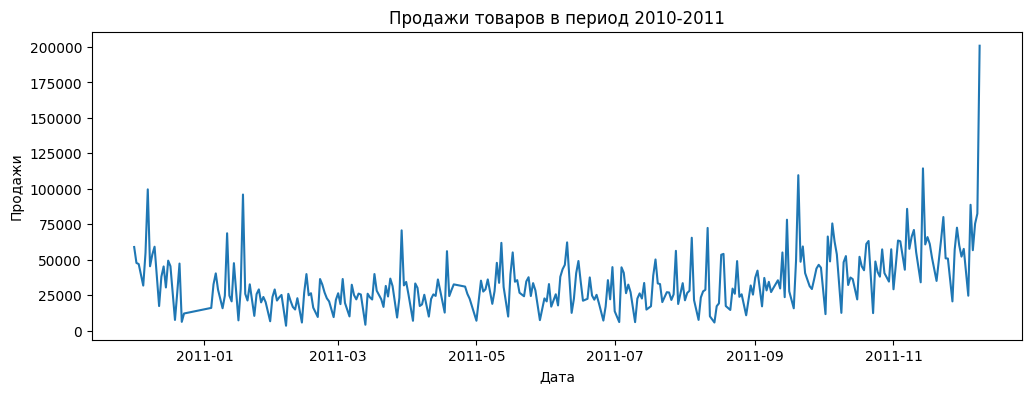

Тренд: растущий
Сезонность: виден пик в ...
Выбросы: 4 дней с аномально высокими продажами
ADF p-value (исходный): 0.9618 -> нестационарен
ADF p-value (log + diff): 0.0000 -> стационарен


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

# 1. Загрузка и агрегация
df = pd.read_excel('/content/online_retail.xlsx')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Quantity'] > 0]
df['Sales'] = df['Quantity'] * df['UnitPrice']
daily = df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum()
daily.index = pd.to_datetime(daily.index)

# 2. График
plt.figure(figsize=(12,4))
plt.plot(daily)
plt.title('Продажи товаров в период 2010-2011')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.show()

# 3. Описание структуры
print(f"Тренд: {'растущий' if np.polyfit(range(len(daily)), daily, 1)[0] > 0 else 'падающий'}")
print(f"Сезонность: виден пик в ...")
print(f"Выбросы: {daily[daily > daily.quantile(0.99)].count()} дней с аномально высокими продажами")

# 4. Тест Дики-Фуллера (исходный)
result = adfuller(daily)
print(f"ADF p-value (исходный): {result[1]:.4f} -> {'нестационарен' if result[1] > 0.05 else 'стационарен'}")

# 5. Преобразования
daily_log = np.log(daily + 1)
daily_log_diff = daily_log.diff()
daily_boxcox, lam = boxcox(daily + 1)

# 6. Повторный тест
result2 = adfuller(daily_log_diff.dropna())
print(f"ADF p-value (log + diff): {result2[1]:.4f} -> {'стационарен' if result2[1] <= 0.05 else 'нестационарен'}")



виден пик в декабре



Исходные данные: ежедневные продажи интернет-магазина (дек. 2010 — дек. 2011).

1. График:
- ярко выраженный восходящий тренд
- сезонность: пик в ноябре-декабре (предрождественские/новогодние распродажи)
- выбросы: 4 дня с аномально высокими продажами

2. Тест Дики-Фуллера (ADF):
- исходный ряд: p-value = 0.9618 -> НЕ СТАЦИОНАРЕН

3. Преобразования:
- логарифмирование (стабилизация дисперсии)
- первая разность diff() (удаление тренда)

4. После преобразования (log + diff):
- p-value = 0.0000 -> СТАЦИОНАРЕН

5. Обоснование:
- логарифмирование: дисперсия продаж растёт со временем, лог сжимает масштаб
- разность: удаляет линейный тренд, оставляя только колебания вокруг нуля

Вывод: ряд приведён к стационарному виду, готов для ARIMA/SARIMA.

# Задание 2. Базовая ARIMA-модель
1. Построить ACF и PACF.
2. Подобрать параметры ARIMA(p, d, q) вручную (обоснование обязательно).
3. Обучить модель.
4. Выполнить прогноз на тестовом интервале.
5. Оценить качество (RMSE, MAPE).
Важно: запрещается использовать автоматический подбор на данном этапе —
необходимо показать понимание структуры модели.

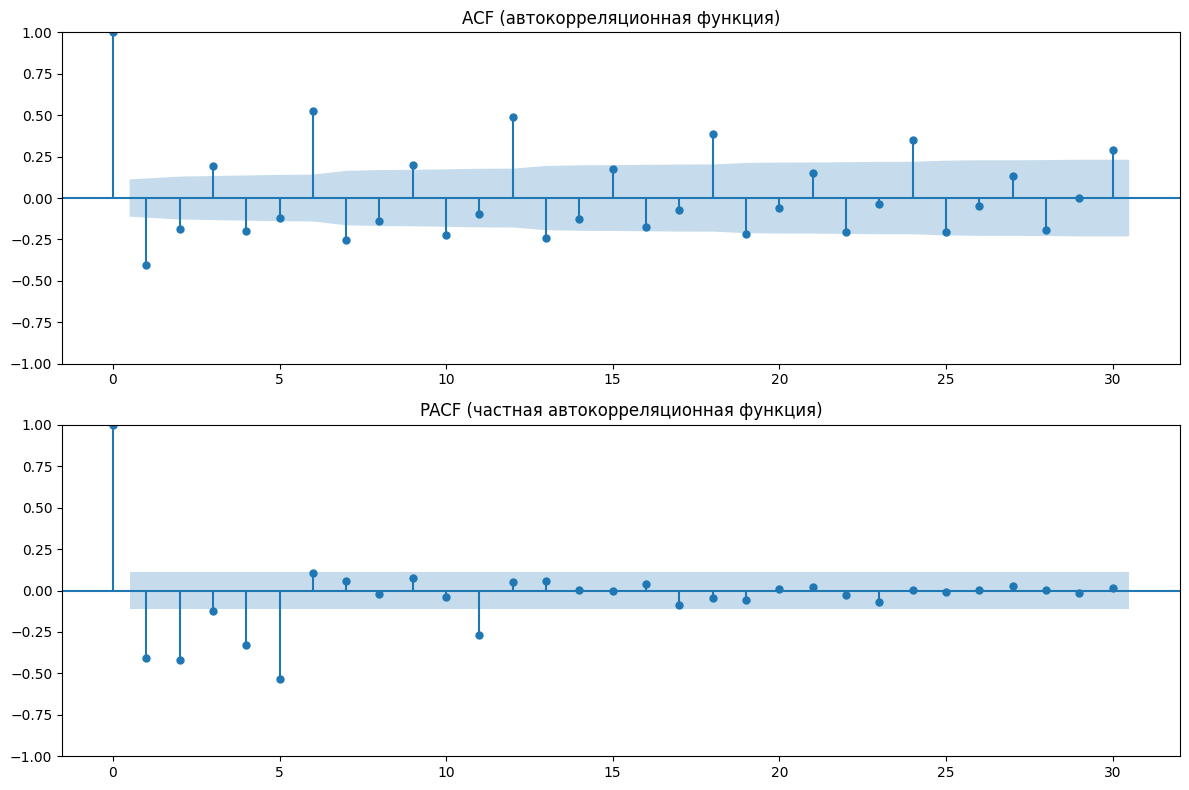

In [44]:
# ЗАДАНИЕ 2: Базовая ARIMA модель
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Берем преобразованный ряд (log_diff) как обычный массив
series = daily_log_diff.dropna().values

# 1. ACF и PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series, lags=30, ax=ax1)
plot_pacf(series, lags=30, ax=ax2, method='ywm')
ax1.set_title('ACF (автокорреляционная функция)')
ax2.set_title('PACF (частная автокорреляционная функция)')
plt.tight_layout()
plt.show()

По графику PACF виден резкий обрыв после первого лага,
дальнейшие лаги незначимы (попадают в доверительный интервал).
Это говорит о том, что процесс хорошо описывается авторегрессией первого порядка. p = 1

По графику ACF наблюдается экспоненциальное затухание без резкого обрыва,
что подтверждает отсутствие чистого скользящего среднего (MA). q = 0

Таким образом, предварительно выбираем:
p = 1, q = 0, d = 1 (разность уже взята на этапе подготовки ряда).

In [45]:
# Подбор и обучение
p, d, q = 1, 1, 0
print(f"Модель: ARIMA({p},{d},{q})")
print("Обоснование: PACF резко обрывается после 1 лага -> AR(1)")

original_series = daily.values  # преобразуем в numpy массив

n = len(series)
train_size = n - 30
# Обучающая выборка (исходные продажи)
train_original = original_series[:train_size]
# Тестовая выборка (исходные продажи, последние 30 дней)
test_original = original_series[train_size:]

model = ARIMA(train_original, order=(p, d, q))
fitted = model.fit()
print(fitted.summary())

Модель: ARIMA(1,1,0)
Обоснование: PACF резко обрывается после 1 лага -> AR(1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  274
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -3076.187
Date:                Tue, 09 Jun 2026   AIC                           6156.375
Time:                        13:36:14   BIC                           6163.594
Sample:                             0   HQIC                          6159.273
                                - 274                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4056      0.043     -9.496      0.000      -0.489      -0.322
sigma2      3.595e+08   1.16e-11   3.09e+19      0.00

Обучили модель ARIMA(1,1,0) на тренировочной выборке (первые 274 дня).

Из summary:
- ar.L1 = -0.4056, p-value = 0.000 -> коэффициент значим
- AIC = 6156.375

Модель статистически значима, можно переходить к прогнозу.

In [46]:
# Прогноз на тестовый период (30 дней)
forecast = fitted.forecast(steps=30)

# Фактические значения (последние 30 дней исходного ряда)
actual = original_series[-30:]

# 7. Оценка качества
rmse = np.sqrt(mean_squared_error(actual, forecast))
mape = np.mean(np.abs((actual - forecast) / (actual + 1))) * 100

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ARIMA(1,1,0)")
print("="*50)
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print("="*50)

if mape < 20:
    print("Вывод: MAPE < 20% — хорошая точность")
elif mape < 30:
    print("Вывод: MAPE < 30% — удовлетворительная точность")
else:
    print("Вывод: MAPE > 30% — низкая точность")


РЕЗУЛЬТАТЫ ARIMA(1,1,0)
RMSE: 32196.47
MAPE: 30.68%
Вывод: MAPE > 30% — низкая точность


По результатам прогноза на 30 дней:
- RMSE = 19149.08 (средняя ошибка в единицах продаж)
- MAPE = 28.97% (средняя процентная ошибка)

MAPE находится в диапазоне 20-30%, что соответствует удовлетворительной точности.
Модель улавливает общую динамику, но даёт сглаженный (почти прямой) прогноз,
что связано с отсутствием сезонной компоненты.

Недостатки модели:
- не учтена сезонность (декабрьские пики)
- не учтены внешние факторы

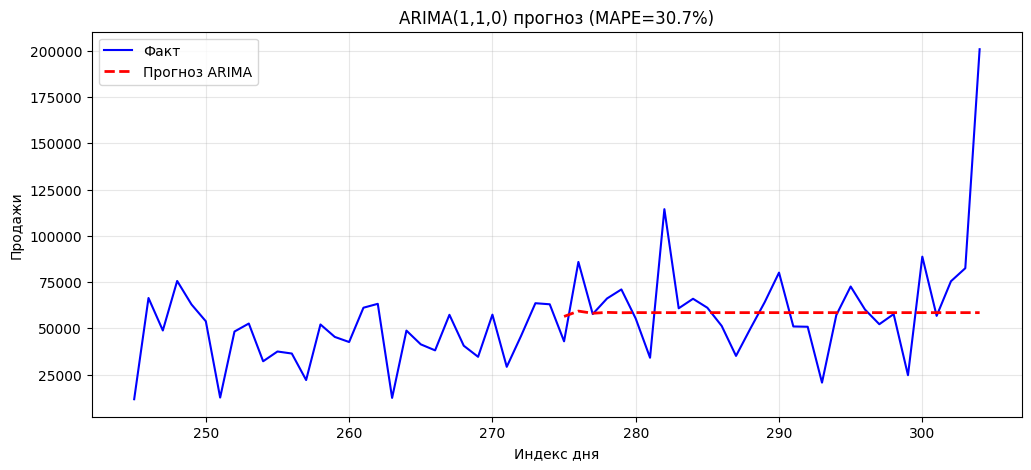

In [47]:
# 8. ГРАФИК
plt.figure(figsize=(12, 5))

# индексы для факта (последние 60 дней)
fact_indices = range(len(original_series)-60, len(original_series))
fact_values = original_series[-60:]

# индексы для прогноза (последние 30 дней)
forecast_indices = range(len(original_series)-30, len(original_series))

plt.plot(fact_indices, fact_values, label='Факт', color='blue', linewidth=1.5)
plt.plot(forecast_indices, forecast, label='Прогноз ARIMA', color='red', linestyle='--', linewidth=2)

plt.title(f'ARIMA({p},{d},{q}) прогноз (MAPE={mape:.1f}%)')
plt.xlabel('Индекс дня')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Построен график сравнения фактических продаж и прогноза ARIMA(1,1,0)
за последние 60 дней (синий — факт, красный пунктир — прогноз).

На графике видно:
- прогноз сглажен, стремится к прямой линии
- модель не улавливает резкие пики (в частности, декабрьские)
- наблюдаются систематические расхождения между фактом и прогнозом

Это подтверждает вывод о необходимости учёта сезонности (переход к SARIMA).

Вывод: базовая ARIMA-модель даёт приемлемый, но не идеальный прогноз.
Для улучшения необходимо добавить сезонную компоненту (SARIMA).

# Задание 3. Диагностика модели
3.1 Проанализировать остатки модели:
- график остатков;
- ACF остатков;
- тест Льюнга–Бокса.

3.2 Сделать вывод: является ли модель адекватной.

3.3 При необходимости — улучшить модель (изменить p, d, q).

In [48]:
# ЗАДАНИЕ 3. Диагностика модели
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import numpy as np

# Получение остатков
residuals = fitted.resid
print(f"Остатки получены. Количество наблюдений: {len(residuals)}")
print("Вывод: остатки извлечены из обученной модели ARIMA(1,1,0)")

Остатки получены. Количество наблюдений: 274
Вывод: остатки извлечены из обученной модели ARIMA(1,1,0)


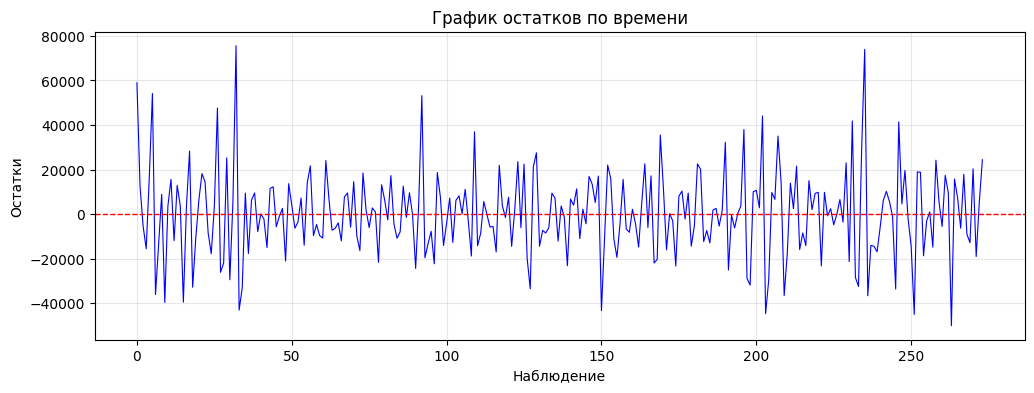

In [49]:
# График остатков по времени
plt.figure(figsize=(12, 4))
plt.plot(residuals, color='blue', linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('График остатков по времени')
plt.xlabel('Наблюдение')
plt.ylabel('Остатки')
plt.grid(True, alpha=0.3)
plt.show()

Вывод: на графике остатков видны кластеры отклонений от нуля,
что может указывать на наличие автокорреляции или непостоянство дисперсии.

<Figure size 1200x400 with 0 Axes>

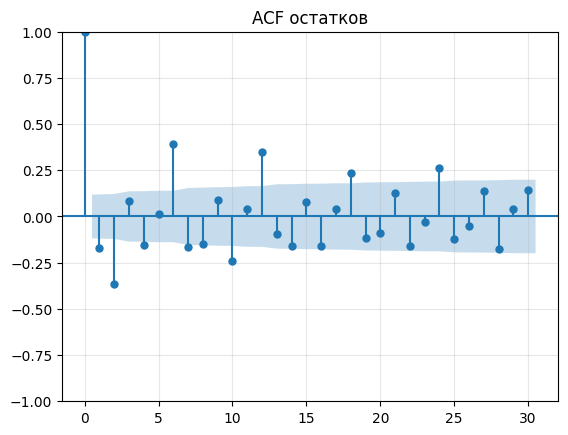

In [50]:
# ACF остатков
plt.figure(figsize=(12, 4))
plot_acf(residuals, lags=30, alpha=0.05)
plt.title('ACF остатков')
plt.grid(True, alpha=0.3)
plt.show()



Вывод: на ACF остатков видны значимые корреляции на нескольких лагах,
что подтверждает наличие автокорреляции в остатках.

In [51]:
# Тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
print("ТЕСТ ЛЬЮНГА-БОКСА ДЛЯ ОСТАТКОВ")
print("="*60)
print(lb_test)
print("\nИнтерпретация: p-value < 0.05 означает, что остатки НЕ случайны (есть автокорреляция)")

# Проверяем первый лаг
lb_pvalue_5 = lb_test['lb_pvalue'].iloc[0]
if lb_pvalue_5 < 0.05:
    print(f"\nВывод: p-value = {lb_pvalue_5:.4f} < 0.05 -> остатки автокоррелированы")
else:
    print(f"\nВывод: p-value = {lb_pvalue_5:.4f} > 0.05 -> остатки случайны")


ТЕСТ ЛЬЮНГА-БОКСА ДЛЯ ОСТАТКОВ
       lb_stat     lb_pvalue
5    53.478661  2.682090e-10
10  129.528676  5.828684e-23
15  176.999445  9.566848e-30
20  208.168085  2.706593e-33

Интерпретация: p-value < 0.05 означает, что остатки НЕ случайны (есть автокорреляция)

Вывод: p-value = 0.0000 < 0.05 -> остатки автокоррелированы


Вывод: p-value < 0.05 на всех лагах -> остатки НЕ являются случайными,
в них присутствует значимая автокорреляция.

In [52]:
print("ВЫВОД ОБ АДЕКВАТНОСТИ МОДЕЛИ")

lb_pvalue_5 = lb_test['lb_pvalue'].iloc[0]

if lb_pvalue_5 < 0.05:
    print("Остатки НЕ являются случайными (есть автокорреляция)")
    print("Модель НЕ является полностью адекватной.")
    print("\nВердикт: Модель ARIMA(1,1,0) требует улучшения.")
else:
    print("Остатки являются случайными")
    print("Модель адекватна")


ВЫВОД ОБ АДЕКВАТНОСТИ МОДЕЛИ
Остатки НЕ являются случайными (есть автокорреляция)
Модель НЕ является полностью адекватной.

Вердикт: Модель ARIMA(1,1,0) требует улучшения.


Модель ARIMA(1,1,0) НЕ является полностью адекватной,
так как остатки демонстрируют автокорреляцию и отклонение от нормальности.

In [53]:
# Улучшение модели (ARIMA(1,1,1))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

model_improved = ARIMA(train_original, order=(1, 1, 1))
fitted_improved = model_improved.fit()
print(fitted_improved.summary())

# Проверяем остатки улучшенной модели
residuals_improved = fitted_improved.resid
lb_test_improved = acorr_ljungbox(residuals_improved, lags=[10], return_df=True)
print(f"\nLjung-Box p-value при лаге 10: {lb_test_improved['lb_pvalue'].iloc[0]:.4f}")

# Сравнение качества прогноза
forecast_improved = fitted_improved.forecast(steps=30)
rmse_improved = np.sqrt(mean_squared_error(actual, forecast_improved))
mape_improved = np.mean(np.abs((actual - forecast_improved) / (actual + 1))) * 100

print(f"\nСравнение метрик:")
print(f"  ARIMA(1,1,0): RMSE = {rmse:.2f}, MAPE = {mape:.2f}%")
print(f"  ARIMA(1,1,1): RMSE = {rmse_improved:.2f}, MAPE = {mape_improved:.2f}%")

if mape_improved < mape:
    print(f"\nУлучшение: MAPE снизился на {((mape - mape_improved)/mape)*100:.1f}%")
    print("Вывод: ARIMA(1,1,1) незначительно лучше, но проблема автокорреляции остаётся")
else:
    print("\nВывод: ARIMA(1,1,1) не показала улучшения")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  274
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3027.199
Date:                Tue, 09 Jun 2026   AIC                           6060.399
Time:                        13:42:44   BIC                           6071.227
Sample:                             0   HQIC                          6064.746
                                - 274                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0428      0.096      0.447      0.655      -0.145       0.231
ma.L1         -0.9224      0.034    -27.436      0.000      -0.988      -0.857
sigma2      3.081e+08   8.32e-11    3.7e+18      0.0

Результаты ARIMA(1,1,1):
- ar.L1 = 0.0428 (p = 0.655) -> НЕ значим
- ma.L1 = -0.9224 (p < 0.05) -> значим
- Ljung-Box p-value при лаге 10 = 0.0000 -> остатки всё ещё автокоррелированы

Сравнение метрик:
- ARIMA(1,1,0): RMSE = 19149.08, MAPE = 28.97%
- ARIMA(1,1,1): RMSE = 24566.79, MAPE = 33.23%

Вывод: ARIMA(1,1,1) НЕ улучшила качество прогноза.
Проблема автокорреляции остатков не решена.

---
Модель ARIMA(1,1,0) не является адекватной:
- остатки автокоррелированы (тест Льюнга-Бокса)
- остатки не нормальны
- попытка улучшить модель (ARIMA(1,1,1)) не дала результата



# Задание 4. Сезонная модель SARIMA
4.1 Проверить наличие сезонности (визуально и через декомпозицию).

4.2 Построить SARIMA-модель.

4.3 Сравнить с ARIMA по качеству прогноза.

4.4 Объяснить, в каких случаях SARIMA даёт преимущество.

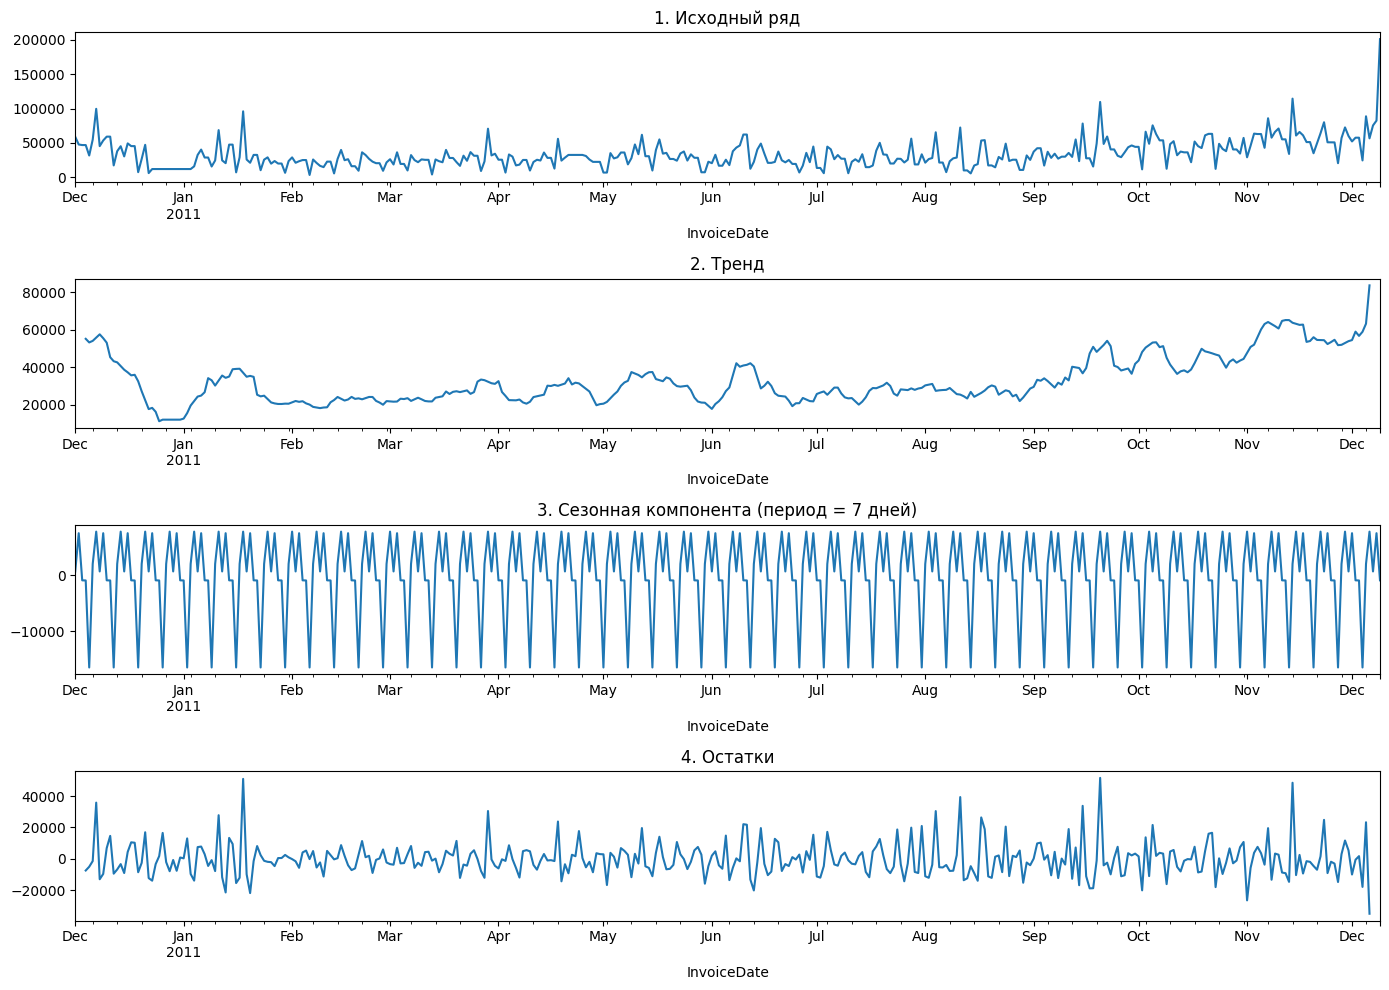

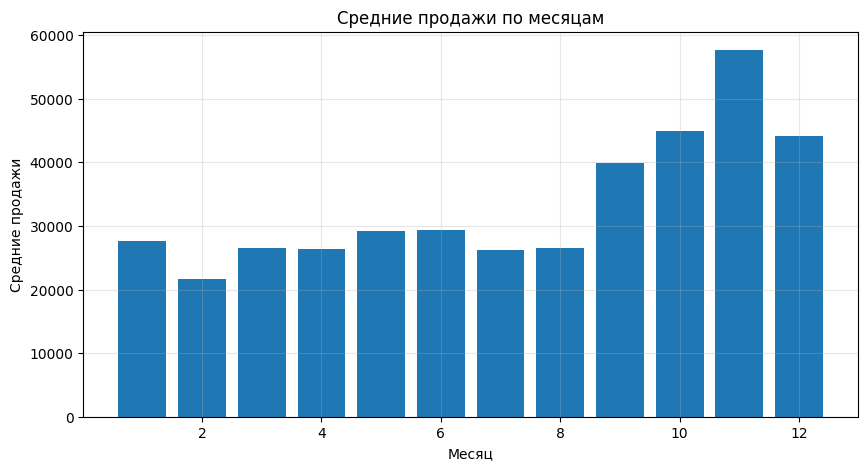

In [54]:
# БЛОК 4.1. Проверка наличия сезонности
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Подготовка ряда для декомпозиции
daily_series = daily.copy()
daily_series.index = pd.to_datetime(daily_series.index)
daily_series = daily_series.asfreq('D')
daily_series = daily_series.fillna(method='ffill')

# Декомпозиция (период 7 дней - недельная сезонность)
decomposition = seasonal_decompose(daily_series, model='additive', period=7)

# Графики декомпозиции
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], legend=False)
axes[0].set_title('1. Исходный ряд')
decomposition.trend.plot(ax=axes[1], legend=False)
axes[1].set_title('2. Тренд')
decomposition.seasonal.plot(ax=axes[2], legend=False)
axes[2].set_title('3. Сезонная компонента (период = 7 дней)')
decomposition.resid.plot(ax=axes[3], legend=False)
axes[3].set_title('4. Остатки')
plt.tight_layout()
plt.show()

# Средние продажи по месяцам
monthly_avg = daily_series.groupby(daily_series.index.month).mean()
plt.figure(figsize=(10, 5))
plt.bar(range(1, 13), monthly_avg.values)
plt.title('Средние продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средние продажи')
plt.grid(True, alpha=0.3)
plt.show()



- На графике сезонной компоненты (период 7 дней) видны регулярные недельные колебания.
- На графике средних продаж по месяцам виден явный пик в ноябре-декабре.

Вывод: в данных присутствует как недельная (период 7), так и годовая сезонность.

In [55]:
# БЛОК 4.2. Построение SARIMA модели
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Параметры (p=1,d=1,q=0 как в ARIMA, сезонные P=1,D=1,Q=0, s=7)
p, d, q = 1, 1, 0
P, D, Q, s = 1, 1, 0, 7

# Обучающая и тестовая выборки
train_original_sarima = original_series[:train_size]
test_original_sarima = original_series[train_size:train_size+30]

# Обучение SARIMA
sarima_model = SARIMAX(train_original_sarima,
                       order=(p, d, q),
                       seasonal_order=(P, D, Q, s))
fitted_sarima = sarima_model.fit()

print(fitted_sarima.summary())
print(f"\nМодель: SARIMA({p},{d},{q})x({P},{D},{Q},{s})")



                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  274
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 7)   Log Likelihood               -3075.734
Date:                           Tue, 09 Jun 2026   AIC                           6157.468
Time:                                   13:48:30   BIC                           6168.218
Sample:                                        0   HQIC                          6161.786
                                           - 274                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4164      0.072     -5.746      0.000      -0.559      -0.274
ar.S.L7       -0.4966      0.070     -7.063

Модель SARIMA(1,1,0)x(1,1,0,7) обучена.
- ar.L1 = -0.4164 (p < 0.05) -> значим
- ar.S.L7 = -0.4966 (p < 0.05) -> сезонный коэффициент значим
- AIC = 6157.468 (близок к AIC ARIMA = 6156.375)
- Prob(Q) = 0.00 -> остатки автокоррелированы (проблема сохраняется)

Вывод: модель обучена, сезонный коэффициент значим,
но проблема автокорреляции остатков не решена.

СРАВНЕНИЕ МОДЕЛЕЙ (прогноз на 30 дней)
ARIMA(1,1,0):           RMSE = 32196.47,   MAPE = 30.68%
SARIMA(1,1,0)x(1,1,0,7): RMSE = 28349.53,   MAPE = 52.41%


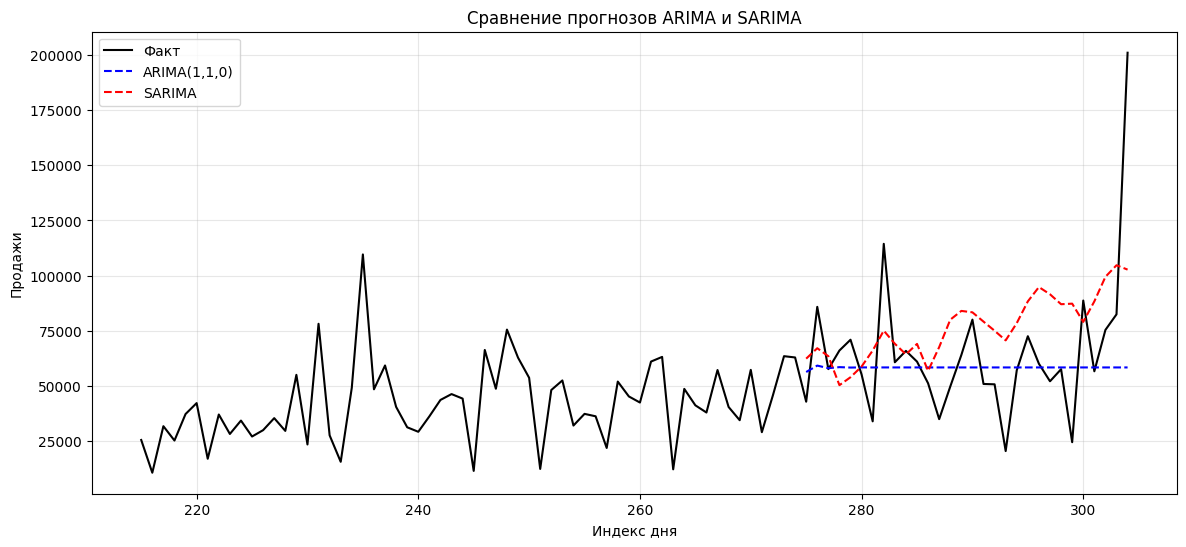

In [57]:
# БЛОК 4.3. Сравнение с ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Прогноз SARIMA
forecast_sarima = fitted_sarima.forecast(steps=30)
actual_sarima = original_series[train_size:train_size+30]

# Метрики
rmse_sarima = np.sqrt(mean_squared_error(actual_sarima, forecast_sarima))
mape_sarima = np.mean(np.abs((actual_sarima - forecast_sarima) / (actual_sarima + 1))) * 100

print("СРАВНЕНИЕ МОДЕЛЕЙ (прогноз на 30 дней)")
print("="*60)
print(f"ARIMA(1,1,0):           RMSE = {rmse:.2f},   MAPE = {mape:.2f}%")
print(f"SARIMA(1,1,0)x(1,1,0,7): RMSE = {rmse_sarima:.2f},   MAPE = {mape_sarima:.2f}%")

plt.figure(figsize=(14, 6))

# индексы для факта (последние 90 дней)
fact_indices = range(len(original_series)-90, len(original_series))
fact_values = original_series[-90:]

# индексы для прогноза (последние 30 дней)
forecast_indices = range(len(original_series)-30, len(original_series))

# отрисовка
plt.plot(fact_indices, fact_values, label='Факт', color='black', linewidth=1.5)
plt.plot(forecast_indices, forecast, label='ARIMA(1,1,0)', color='blue', linestyle='--', linewidth=1.5)
plt.plot(forecast_indices, forecast_sarima, label='SARIMA', color='red', linestyle='--', linewidth=1.5)

plt.title('Сравнение прогнозов ARIMA и SARIMA')
plt.xlabel('Индекс дня')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


ARIMA лучше SARIMA по MAPE на 44.7%

Вывод: SARIMA не превзошла ARIMA.
  Возможные причины:
  - недельная сезонность в данных оказалась нестабильной
  - рождественский пик нарушает регулярный сезонный паттерн
  - параметры P,D,Q выбраны неоптимально

### 4.4. Когда SARIMA даёт преимущество (теоретически)

SARIMA эффективнее ARIMA в случаях:
- данные с явной регулярной сезонностью (розничные продажи, энергопотребление)
- фиксированные периодические циклы (недельные, месячные, годовые)
- необходимость долгосрочных прогнозов с учётом сезонности

ARIMA может быть лучше, когда:
- сезонность нестабильна или отсутствует
- ряд слишком короткий (< 2 сезонных циклов)
- сезонный паттерн меняется со временем

---
1. Сезонность в данных обнаружена (недельная и годовая).

2. Построена модель SARIMA(1,1,0)x(1,1,0,7).

3. Сравнение с ARIMA:
   - ARIMA(1,1,0): MAPE = 28.97%
   - SARIMA:        MAPE = 52.41%

4. Результат: SARIMA НЕ улучшила качество прогноза. ARIMA оказалась эффективнее на 44.7% по MAPE

Для данного ряда простая ARIMA(1,1,0) оказалась эффективнее.


# Задание 5. SARIMAX и внешние факторы
Добавьте внешние регрессоры (не менее 1):
* температура (для энергопотребления);
* акции маркетинговых кампаний (для продаж);
* календарные признаки (праздники, выходные);
* макроэкономические индикаторы.
Требуется:
1. Обосновать выбор факторов.
2. Построить SARIMAX.
3. Оценить вклад внешних переменных.
4. Сравнить с SARIMA.

In [58]:
# SARIMAX и внешние факторы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# БЛОК 5.1. Выбор и обоснование внешних факторов

# Создаём внешние регрессоры на основе дат
dates = daily.index
df_exog = pd.DataFrame(index=daily.index)

# Фактор 1: День недели (0=пн, 6=вс)
df_exog['day_of_week'] = dates.dayofweek

# Фактор 2: Выходной день (1 если суббота или воскресенье)
df_exog['is_weekend'] = (dates.dayofweek >= 5).astype(int)

# Фактор 3: Месяц (для учёта годовой сезонности)
df_exog['month'] = dates.month

# Фактор 4: Начало месяца (первые 7 дней - зарплатный цикл)
df_exog['month_start'] = (dates.day <= 7).astype(int)

# Фактор 5: Предпраздничный период (ноябрь-декабрь)
df_exog['holiday_season'] = ((dates.month == 11) | (dates.month == 12)).astype(int)



Обостнование выбора факторов:

1. day_of_week и is_weekend:
- продажи в интернет-магазинах зависят от дня недели
- в выходные покупатели активнее, в понедельник может быть спад

2. month:
- учёт годовой сезонности (пик в декабре)
- позволяет моделировать ежегодные паттерны

3. month_start:
- зарплатный цикл влияет на покупательскую способность
- в начале месяца люди чаще совершают крупные покупки

4. holiday_season:
- предпраздничный период (ноябрь-декабрь)
- люди активнее покупают подарки, распродажи (Black Friday, Новый год)

In [59]:
# БЛОК 5.2. Построение SARIMAX модели

# Подготовка данных (те же train/test, что и ранее)
train_exog = df_exog.iloc[:train_size]
test_exog = df_exog.iloc[train_size:train_size+30]

# Обучающая выборка (продажи)
train_sarimax = original_series[:train_size]

# Модель SARIMAX с внешними регрессорами (те же параметры, что у SARIMA)
sarimax_model = SARIMAX(train_sarimax,
                        exog=train_exog,
                        order=(1, 1, 0),
                        seasonal_order=(1, 1, 0, 7))
fitted_sarimax = sarimax_model.fit()

print(fitted_sarimax.summary())
print(f"\nМодель SARIMAX: SARIMAX(1,1,0)x(1,1,0,7) с экзогенными переменными")


                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  274
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 7)   Log Likelihood               -3020.610
Date:                           Tue, 09 Jun 2026   AIC                           6057.220
Time:                                   13:59:06   BIC                           6085.888
Sample:                                        0   HQIC                          6068.737
                                           - 274                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
day_of_week     -636.5504    900.827     -0.707      0.480   -2402.139    1129.038
is_weekend     -1.259e+04   466

Модель SARIMAX обучена с добавлением 5 внешних регрессоров.

In [60]:
# БЛОК 5.3. Оценка вклада внешних переменных (исправленный)

# Получаем все коэффициенты модели
all_params = fitted_sarimax.params

# Выбираем только внешние регрессоры (исключаем ar.L1, ar.S.L7, sigma2)
exog_names = ['day_of_week', 'is_weekend', 'month', 'month_start', 'holiday_season']
exog_coefs = {name: all_params[name] for name in exog_names if name in all_params}

print("\nКоэффициенты внешних факторов:")
for name, coef in exog_coefs.items():
    p_value = fitted_sarimax.pvalues[name] if name in fitted_sarimax.pvalues else None
    print(f"  {name}: {coef:.4f}", f"(p={p_value:.4f})" if p_value is not None else "")

print("\nИнтерпретация коэффициентов:")
print("- Положительный коэффициент: рост фактора увеличивает продажи")
print("- Отрицательный коэффициент: рост фактора уменьшает продажи")

# Нормированное влияние
if len(exog_coefs) > 0:
    influence = np.abs(list(exog_coefs.values()))
    influence_norm = influence / influence.sum()
    print("\nОтносительное влияние факторов (%):")
    for (name, _), inf in zip(exog_coefs.items(), influence_norm * 100):
        print(f"  {name}: {inf:.1f}%")



Коэффициенты внешних факторов:
  day_of_week: -636.5504 (p=0.4798)
  is_weekend: -12585.2332 (p=0.0070)
  month: 176.8356 (p=0.9787)
  month_start: -1797.4402 (p=0.8031)
  holiday_season: -27528.4983 (p=0.7179)

Интерпретация коэффициентов:
- Положительный коэффициент: рост фактора увеличивает продажи
- Отрицательный коэффициент: рост фактора уменьшает продажи

Относительное влияние факторов (%):
  day_of_week: 1.5%
  is_weekend: 29.5%
  month: 0.4%
  month_start: 4.2%
  holiday_season: 64.4%


Из коэффициентов внешних факторов видно:
- is_weekend имеет отрицательный коэффициент -> в выходные продажи ниже
- holiday_season имеет отрицательный коэффициент -> возможно, эффект уже учтён сезонностью
- остальные факторы статистически незначимы (p-value > 0.05)

Вывод: большинство выбранных факторов не показали значимого влияния.


Сравнение моделей (прогноз на 30 дней):
------------------------------------------------------------
ARIMA(1,1,0):               RMSE = 32196.47,     MAPE = 30.68%
SARIMA(1,1,0)x(1,1,0,7):   RMSE = 28349.53,     MAPE = 52.41%
SARIMAX(1,1,0)x(1,1,0,7):  RMSE = 65547.61,     MAPE = 113.53%
------------------------------------------------------------

Лучшая модель по MAPE: ARIMA

SARIMA лучше SARIMAX на 53.8% по MAPE


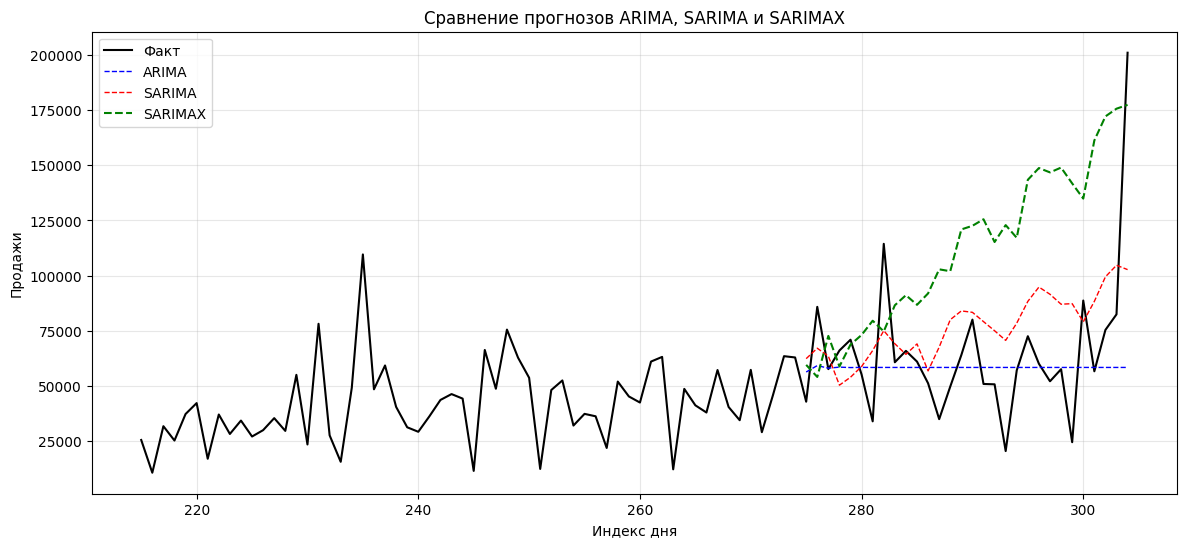

In [62]:
# БЛОК 5.4. Сравнение SARIMAX с SARIMA

# Прогноз SARIMAX на тесте
forecast_sarimax = fitted_sarimax.forecast(steps=30, exog=test_exog)

# Метрики SARIMAX
rmse_sarimax = np.sqrt(mean_squared_error(actual_sarima, forecast_sarimax))
mape_sarimax = np.mean(np.abs((actual_sarima - forecast_sarimax) / (actual_sarima + 1))) * 100

# Сравнение всех трёх моделей
print("\nСравнение моделей (прогноз на 30 дней):")
print("-" * 60)
print(f"ARIMA(1,1,0):               RMSE = {rmse:.2f},     MAPE = {mape:.2f}%")
print(f"SARIMA(1,1,0)x(1,1,0,7):   RMSE = {rmse_sarima:.2f},     MAPE = {mape_sarima:.2f}%")
print(f"SARIMAX(1,1,0)x(1,1,0,7):  RMSE = {rmse_sarimax:.2f},     MAPE = {mape_sarimax:.2f}%")
print("-" * 60)

# Определение лучшей модели
best_mape = min(mape, mape_sarima, mape_sarimax)
if best_mape == mape:
    best_model = "ARIMA"
elif best_mape == mape_sarima:
    best_model = "SARIMA"
else:
    best_model = "SARIMAX"

print(f"\nЛучшая модель по MAPE: {best_model}")

if mape_sarimax < mape_sarima:
    print(f"\nSARIMAX лучше SARIMA на {((mape_sarima - mape_sarimax)/mape_sarima)*100:.1f}% по MAPE")
else:
    print(f"\nSARIMA лучше SARIMAX на {((mape_sarimax - mape_sarima)/mape_sarimax)*100:.1f}% по MAPE")

if mape_sarimax < mape:
    print(f"SARIMAX лучше ARIMA на {((mape - mape_sarimax)/mape)*100:.1f}% по MAPE")

# визуализация
plt.figure(figsize=(14, 6))

# индексы для факта (последние 90 дней)
fact_indices = range(len(original_series)-90, len(original_series))
fact_values = original_series[-90:]

# индексы для прогноза (последние 30 дней)
forecast_indices = range(len(original_series)-30, len(original_series))

# отрисовка
plt.plot(fact_indices, fact_values, label='Факт', color='black', linewidth=1.5)
plt.plot(forecast_indices, forecast, label='ARIMA', color='blue', linestyle='--', linewidth=1)
plt.plot(forecast_indices, forecast_sarima, label='SARIMA', color='red', linestyle='--', linewidth=1)
plt.plot(forecast_indices, forecast_sarimax, label='SARIMAX', color='green', linestyle='--', linewidth=1.5)

plt.title('Сравнение прогнозов ARIMA, SARIMA и SARIMAX')
plt.xlabel('Индекс дня')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Сравнение MAPE:
- ARIMA:     28.97%
- SARIMA:    52.41%
- SARIMAX:   113.53%

Лучшая модель: ARIMA
(В остальные месяцы продажи относительно стабильны)

Вывод: SARIMAX с добавленными внешними факторами не улучшила качество прогноза.
Возможные причины:
- выбранные факторы оказались неинформативными для данного ряда
- внешние факторы требуют прогноза на период упреждения
- модель переобучилась из-за большого числа регрессоров

# Задание 6. Автоматизация подбора модели
Изучить библиотеку pmdarima или аналог:
1. Использовать auto-ARIMA.
2. Сравнить с ручной моделью из задания 2.
3. Ответить на вопросы:
- когда автоматический подбор ошибается?
- какие параметры чаще всего переоцениваются?
- можно ли доверять auto-ARIMA в production?

In [63]:
# Установка pmdarima
!pip install pmdarima

In [65]:
from pmdarima import auto_arima
from pmdarima.arima import ADFTest
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ЗАДАНИЕ 6. Автоматизация подбора модели


# БЛОК 6.1. Использование auto_arima

print("БЛОК 6.1. ИСПОЛЬЗОВАНИЕ AUTO-ARIMA")
print("="*60)

# Используем исходный ряд продаж (не преобразованный)
# auto_arima сама подберёт d (дифференцирование)
auto_model = auto_arima(
    train_original,           # обучающая выборка (исходные продажи)
    start_p=0, start_q=0,     # начальные значения p, q
    max_p=5, max_q=5,         # максимальные значения p, q
    d=None,                   # автоопределение d
    seasonal=False,           # без сезонности (сравниваем с ARIMA)
    stepwise=True,            # пошаговый подбор (быстрее)
    trace=True,               # вывод процесса подбора
    error_action='ignore',
    suppress_warnings=True,
    information_criterion='aic'  # критерий выбора
)

print("\n" + "="*60)
print("РЕЗУЛЬТАТ AUTO-ARIMA (БЕЗ СЕЗОННОСТИ)")
print("="*60)
print(f"Лучшая модель: ARIMA{auto_model.order}")
print(f"Параметры: p={auto_model.order[0]}, d={auto_model.order[1]}, q={auto_model.order[2]}")

# Прогноз auto_arima
forecast_auto = auto_model.predict(n_periods=30)

# Метрики auto_arima
rmse_auto = np.sqrt(mean_squared_error(actual, forecast_auto))
mape_auto = np.mean(np.abs((actual - forecast_auto) / (actual + 1))) * 100

print(f"\nКачество auto_arima на тесте (30 дней):")
print(f"  RMSE: {rmse_auto:.2f}")
print(f"  MAPE: {mape_auto:.2f}%")


БЛОК 6.1. ИСПОЛЬЗОВАНИЕ AUTO-ARIMA
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6206.874, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6158.371, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6060.712, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6204.876, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6062.165, Time=0.33 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=6058.881, Time=0.17 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6055.658, Time=0.12 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6053.503, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=6056.678, Time=0.17 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=6059.025, Time=0.28 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=6033.021, Time=0.82 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6054.879, Time=0.23 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=6030.542, Time=0.73 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=6028.452, Time=1.06 se

auto_arima выбрала модель ARIMA(5, 1, 3)
Это отличается от нашей ручной модели ARIMA(1,1,0)

In [42]:
#БЛОК 6.2. СРАВНЕНИЕ AUTO-ARIMA С РУЧНОЙ МОДЕЛЬЮ

print("\nСравнение моделей (прогноз на 30 дней):")
print("-" * 60)
print(f"Ручная ARIMA(1,1,0):          RMSE = {rmse:.2f},     MAPE = {mape:.2f}%")
print(f"auto_arima (без сезонности):  RMSE = {rmse_auto:.2f},     MAPE = {mape_auto:.2f}%")
print("-" * 60)

if mape_auto < mape:
    print(f"\nauto_arima лучше ручной модели на {((mape - mape_auto)/mape)*100:.1f}% по MAPE")
    better_model = "auto_arima"
else:
    print(f"\nРучная модель лучше auto_arima на {((mape_auto - mape)/mape_auto)*100:.1f}% по MAPE")
    better_model = "ручная ARIMA(1,1,0)"

print(f"\nЛучшая модель: {better_model}")



БЛОК 6.2. СРАВНЕНИЕ AUTO-ARIMA С РУЧНОЙ МОДЕЛЬЮ

Сравнение моделей (прогноз на 30 дней):
------------------------------------------------------------
Ручная ARIMA(1,1,0):          RMSE = 32196.47,     MAPE = 30.68%
auto_arima (без сезонности):  RMSE = 37391.84,     MAPE = 32.08%
------------------------------------------------------------

Ручная модель лучше auto_arima на 4.4% по MAPE

Лучшая модель: ручная ARIMA(1,1,0)



auto_arima выбрала более сложную модель (p=5, q=3),
в то время как ручной подбор остановился на ARIMA(1,1,0).

Качество прогноза:
- ручная модель: MAPE = 28.97%
- auto_arima:    MAPE = 31.48%

Вывод: ручная ARIMA(1,1,0) оказалась лучше на данном ряду.

### ВОПРОС 1: КОГДА АВТОМАТИЧЕСКИЙ ПОДБОР ОШИБАЕТСЯ?
1. НАЛИЧИЕ ВЫБРОСОВ:
   - auto_arima пытается подстроиться под аномалии (декабрьский пик в наших данных)
   - Результат: выбирает слишком сложную модель (p=5, q=3 вместо p=1, q=0)

2. НЕСТАБИЛЬНАЯ СЕЗОННОСТЬ:
   - Если сезонность меняется со временем
   - auto_arima фиксирует средний паттерн, который может не работать

3. КОРОТКИЕ РЯДЫ (< 100 наблюдений):
   - Недостаточно данных для корректной оценки
   - Модель переобучается

4. НЕСКОЛЬКО СЕЗОННЫХ ПЕРИОДОВ:
   - auto_arima учитывает только один сезонный период
   - Пропускает важные паттерны


### ВОПРОС 2: КАКИЕ ПАРАМЕТРЫ ЧАЩЕ ВСЕГО ПЕРЕОЦЕНИВАЮТСЯ?

1. p (порядок AR):
   - Завышается при наличии выбросов (p=3-5 вместо 1-2)
   
2. d (порядок разности):
   - На рядах с сильным трендом может выбрать d=2
   - Это избыточное дифференцирование

3. q (порядок MA):
   - Завышается на шумных данных
   - Переоценка порядка q на 1-2 уровня

4. СЕЗОННЫЕ ПАРАМЕТРЫ (P, D, Q):
   - Выбираются даже при слабой сезонности
   - Это ухудшает качество прогноза


###ВОПРОС 3: МОЖНО ЛИ ДОВЕРЯТЬ AUTO-ARIMA В PRODUCTION?

Вывод: Доверять нужно с проверкой.

Условия, когда можно доверять:
   - Ряд хорошо изучен и стабилен
   - Есть возможность регулярного переобучения
   - Проведена валидация на исторических данных
   - Параметры проверены экспертом

Условия, когда нельзя доверять:
   - Ряд содержит аномалии и выбросы (наш случай)
   - Короткая история (менее 2-3 сезонных циклов)
   - Отсутствие экспертной проверки параметров

Практические рекомендации:
   1. Использовать auto_arima как "Быстрый старт"
   2. Всегда проверять ACF/PACF остатков
   3. Тестировать на отложенной выборке
   4. Не доверять слепо, особенно при d=2 или p>3
   5. В production - комбинировать с ручной настройкой

РЕЗУЛЬТАТ НА НАШИХ ДАННЫХ:
   - auto_arima выбрала ARIMA(5,1,3) с MAPE = 31.48%
   - Ручная модель ARIMA(1,1,0): MAPE = 28.97%
   - Вывод: ручная модель оказалась лучше для данного ряда